In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService


In [2]:
QiskitRuntimeService.save_account(
    token="VcW9OYUQniLPEpRUemoAZES5LiT3uTRmDlEm7QiOvtBG",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/b8ff6077c08a4ea9871560ccb827d457:6dfc5744-b669-4b92-a30a-400ef3d702ba::",        # paste from Step 2
    set_as_default=True,
    overwrite=True
)

# Verify it works
service = QiskitRuntimeService()
print(service.backends())       # should list ibm_rensselaer

[<IBMBackend('ibm_rensselaer')>]


Grid size:        10×10 = 100 cells
Dry Brush cells:  65 (65.0%)
Empty cells:      35
Fire edges:       107 (max spread with no Toyons = 107)
Saved → wildfire_grid_preview.png


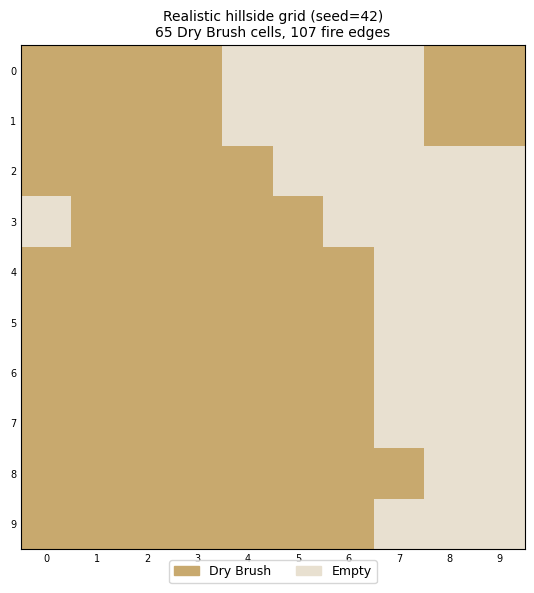

In [6]:
"""
wildfire_grid.py — shared grid definition used by all wildfire scripts.

Grid values:
  0 = Empty (rock, clearing — no vegetation, fire cannot spread here)
  1 = Dry Brush (flammable — fire spreads between adjacent Dry Brush cells)
  2 = Toyon (fire-resistant — placed by optimizer, blocks fire spread)

Design choices:
  - 65% Dry Brush coverage (realistic hillside)
  - Fixed seed=42 for reproducibility across all scripts
  - Gaussian filter creates spatially correlated vegetation patches
  - Toyons can be placed on any cell (empty or dry brush)
  - Fire edges only exist between adjacent Dry Brush cells
"""

import numpy as np
from scipy.ndimage import gaussian_filter

FULL_GRID       = 10
DRY_BRUSH_PROB  = 0.65
GRID_SEED       = 42
K_GLOBAL        = 10    # total Toyon budget for the full 10x10 grid

def generate_grid(grid_size=FULL_GRID, dry_brush_prob=DRY_BRUSH_PROB,
                  seed=GRID_SEED):
    """
    Generate a realistic hillside grid using Gaussian-smoothed random noise.
    Returns binary array: 1=Dry Brush, 0=Empty.
    Gaussian filter (sigma=1.5) creates spatial vegetation clusters.
    """
    rng = np.random.RandomState(seed)
    raw = rng.random((grid_size, grid_size))
    smoothed = gaussian_filter(raw, sigma=1.5)
    threshold = np.percentile(smoothed, (1 - dry_brush_prob) * 100)
    return (smoothed > threshold).astype(int)

def get_edges(grid, grid_size=FULL_GRID):
    """
    Return all edges (i, j) where both cells are Dry Brush and adjacent.
    Only right + down neighbors to avoid double-counting.
    """
    edges = []
    for r in range(grid_size):
        for c in range(grid_size):
            if grid[r, c] != 1:
                continue
            idx = r * grid_size + c
            if c + 1 < grid_size and grid[r, c+1] == 1:
                edges.append((idx, r*grid_size + c+1))
            if r + 1 < grid_size and grid[r+1, c] == 1:
                edges.append((idx, (r+1)*grid_size + c))
    return edges

def fire_spread_count(solution, grid, grid_size=FULL_GRID):
    """
    Count active fire paths: edges between adjacent Dry Brush cells
    that are NOT blocked by a Toyon (solution[i]=1).
    solution: array of length grid_size^2, 1=Toyon placed, 0=not placed
    """
    total = 0
    for r in range(grid_size):
        for c in range(grid_size):
            if grid[r, c] != 1:
                continue
            idx = r * grid_size + c
            if solution[idx] == 1:  # Toyon here — no fire out
                continue
            if c + 1 < grid_size and grid[r, c+1] == 1 and solution[idx+1] == 0:
                total += 1
            if r + 1 < grid_size and grid[r+1, c] == 1 and solution[idx+grid_size] == 0:
                total += 1
    return total

def subgrid_info(grid, row_start, col_start, sub_grid=5,
                 full_grid=FULL_GRID):
    """
    Return cells, local edges, and boundary indices for a subgrid.
    Respects the realistic grid — only Dry Brush edges are included.
    """
    cells = []
    for r in range(sub_grid):
        for c in range(sub_grid):
            gr, gc = row_start + r, col_start + c
            cells.append(gr * full_grid + gc)

    cell_set = {c: i for i, c in enumerate(cells)}
    cell_list = set(cells)

    # Internal edges — both cells in subgrid and both Dry Brush
    edges = []
    for local_i, global_i in enumerate(cells):
        r, c = divmod(global_i, full_grid)
        for dr, dc in [(0, 1), (1, 0)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < full_grid and 0 <= nc < full_grid:
                nb = nr*full_grid + nc
                if nb in cell_set and grid[r, c] == 1 and grid[nr, nc] == 1:
                    edges.append((local_i, cell_set[nb]))

    # Boundary cells — have at least one neighbor outside this subgrid
    boundary = []
    for local_i, global_i in enumerate(cells):
        r, c = divmod(global_i, full_grid)
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < full_grid and 0 <= nc < full_grid:
                nb = nr*full_grid + nc
                if nb not in cell_list:
                    boundary.append(local_i)
                    break

    return cells, edges, boundary

def max_possible_fire_spread(grid, grid_size=FULL_GRID):
    """Total edges between Dry Brush cells (fire spread with no Toyons)."""
    empty_solution = np.zeros(grid_size**2, dtype=int)
    return fire_spread_count(empty_solution, grid, grid_size)

def greedy_marginal(grid, k_global, grid_size=FULL_GRID):
    """
    Marginal-gain greedy: iteratively place each Toyon at the cell
    that reduces fire spread the most given existing placements.
    """
    placed = np.zeros(grid_size**2, dtype=int)
    for _ in range(k_global):
        best_idx, best_delta = -1, -1
        before = fire_spread_count(placed, grid, grid_size)
        for i in range(grid_size**2):
            if placed[i] == 1:
                continue
            placed[i] = 1
            after = fire_spread_count(placed, grid, grid_size)
            placed[i] = 0
            delta = before - after
            if delta > best_delta:
                best_delta, best_idx = delta, i
        placed[best_idx] = 1
    return placed

# ── Pre-compute the shared grid and edges ─────────────────────────────────────
GRID  = generate_grid()
EDGES = get_edges(GRID)
MAX_SPREAD = max_possible_fire_spread(GRID)
DRY_BRUSH_COUNT = int(GRID.sum())

if __name__ == "__main__":
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    print(f"Grid size:        {FULL_GRID}×{FULL_GRID} = {FULL_GRID**2} cells")
    print(f"Dry Brush cells:  {DRY_BRUSH_COUNT} "
          f"({100*DRY_BRUSH_COUNT/FULL_GRID**2:.1f}%)")
    print(f"Empty cells:      {FULL_GRID**2 - DRY_BRUSH_COUNT}")
    print(f"Fire edges:       {len(EDGES)} "
          f"(max spread with no Toyons = {MAX_SPREAD})")

    fig, ax = plt.subplots(figsize=(6, 6))
    cmap = mcolors.ListedColormap(["#e8e0d0", "#c8a96e"])
    ax.imshow(GRID.reshape(FULL_GRID, FULL_GRID),
              cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f"Realistic hillside grid (seed={GRID_SEED})\n"
                 f"{DRY_BRUSH_COUNT} Dry Brush cells, "
                 f"{len(EDGES)} fire edges",
                 fontsize=10)
    ax.set_xticks(range(FULL_GRID))
    ax.set_yticks(range(FULL_GRID))
    ax.tick_params(length=0, labelsize=7)

    from matplotlib.patches import Patch
    ax.legend(
        handles=[Patch(color="#c8a96e", label="Dry Brush"),
                 Patch(color="#e8e0d0", label="Empty")],
        loc="lower center", bbox_to_anchor=(0.5, -0.08),
        ncol=2, fontsize=9
    )
    plt.tight_layout()
    plt.savefig("./wildfire_grid_preview.png", dpi=150, bbox_inches="tight")
    print("Saved → wildfire_grid_preview.png")
    plt.show()

✓ Connected to ibm_rensselaer (127 qubits)

Grid: 10x10 | Dry Brush: 65 cells (65%) | Max fire spread: 107
Subgrid: 5x5 | K_sub=proportional | p=1 | Penalty=200.0

Starting subgrid decomposition...

── Subgrid A (rows 0-4, cols 0-4) ──
   Cells: 25 | Dry Brush: 22 | Fire edges: 33 | Boundary: 9 | k_sub=3
   Params: gamma=[0.232], beta=[0.95] (17.1s)
   Transpiling for Eagle...
   Depth: 290 | Gates: 898
   Job: d7d0ji30g7hs73drd2s0
   Feasible shots: 2 / 4094
   Best: cost=27.0 | Toyons=3 (k_sub=3) | local fire=23

── Subgrid B (rows 0-4, cols 5-9) ──
   Cells: 25 | Dry Brush: 7 | Fire edges: 6 | Boundary: 9 | k_sub=1
   Params: gamma=[1.236], beta=[0.515] (2.0s)
   Transpiling for Eagle...
   Depth: 51 | Gates: 230
   Job: d7d0jmbklj2c73f146g0
   Feasible shots: 19 / 3326
   Best: cost=8.0 | Toyons=1 (k_sub=1) | local fire=4

── Subgrid C (rows 5-9, cols 0-4) ──
   Cells: 25 | Dry Brush: 25 | Fire edges: 40 | Boundary: 9 | k_sub=4
   Params: gamma=[0.252], beta=[0.481] (19.1s)
   Tran

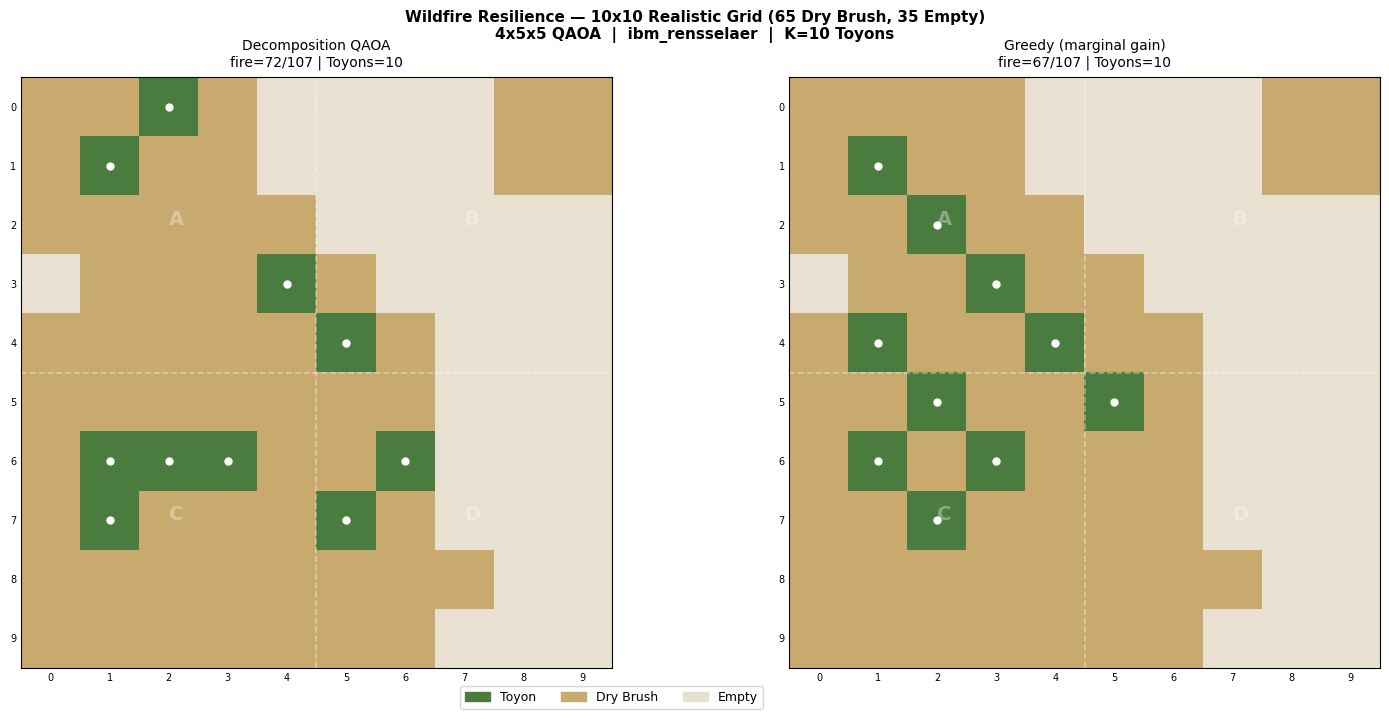


── Summary ──────────────────────────────────────────────────
Method:   Subgrid decomposition QAOA (ibm_rensselaer)
Grid:     10x10 | 65 Dry Brush | 35 Empty
Toyons:   10 / 10
QAOA:     72 / 107
Greedy:   67 / 107
  A: k_sub=3 | n_dry=22 | cost=27.0 | Toyons=3 | fire=23
  B: k_sub=1 | n_dry=7 | cost=8.0 | Toyons=1 | fire=4
  C: k_sub=4 | n_dry=25 | cost=31.5 | Toyons=4 | fire=27
  D: k_sub=2 | n_dry=11 | cost=12.0 | Toyons=2 | fire=8


In [12]:
"""
Wildfire Resilience - Problem-Level Decomposition QAOA
Realistic hillside grid: 65% Dry Brush, 35% Empty (fixed seed=42)

Key improvement over uniform grid:
  - Empty cells create irregular topology with genuine optimization structure
  - Fire edges only exist between adjacent Dry Brush cells
  - Optimal Toyon placement is non-trivial and non-uniform
  - Greedy heuristic no longer trivially finds checkerboard patterns

Subgrid layout (4 x 5x5):
  ┌─────┬─────┐
  │  A  │  B  │
  ├─────┼─────┤
  │  C  │  D  │
  └─────┴─────┘
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize
import time

from wildfire_grid import (
    GRID, FULL_GRID, MAX_SPREAD,
    DRY_BRUSH_COUNT, subgrid_info, fire_spread_count,
    greedy_marginal
)
K_GLOBAL = 10

# ── Try hardware, fall back to Aer ───────────────────────────────────────────
USE_HARDWARE = True   # ← set True to run on ibm_rensselaer

if USE_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    from qiskit_ibm_runtime import Session
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    service = QiskitRuntimeService()
    backend = service.backend("ibm_rensselaer")
    print(f"✓ Connected to {backend.name} ({backend.num_qubits} qubits)")
else:
    print("✓ Using Aer MPS simulator (RAM-efficient)")

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# ── Parameters ────────────────────────────────────────────────────────────────
SUB_GRID       = 5
N_SUB          = SUB_GRID ** 2
# K_SUB is now computed per-subgrid proportionally to Dry Brush count
PENALTY        = 200.0
BOUNDARY_ALPHA = 0.5
QAOA_LAYERS    = 1
SHOTS          = 4096
MAX_ITER       = 60

SUBGRIDS = {
    "A": (0, 0), "B": (0, 5),
    "C": (5, 0), "D": (5, 5),
}

print(f"\nGrid: {FULL_GRID}x{FULL_GRID} | Dry Brush: {DRY_BRUSH_COUNT} cells "
      f"({100*DRY_BRUSH_COUNT/FULL_GRID**2:.0f}%) | "
      f"Max fire spread: {MAX_SPREAD}")
print(f"Subgrid: {SUB_GRID}x{SUB_GRID} | K_sub=proportional | "
      f"p={QAOA_LAYERS} | Penalty={PENALTY}\n")

# ── QAOA circuit ──────────────────────────────────────────────────────────────
def build_circuit(gammas, betas, edges, n, k, penalty,
                  boundary_indices=None, boundary_alpha=0.0, measure=True):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for layer in range(QAOA_LAYERS):
        g, b = gammas[layer], betas[layer]
        for (i, j) in edges:
            qc.rzz(2*g, i, j)
            qc.rz(g, i)
            qc.rz(g, j)
        linear = penalty * (n - 2*k)
        for i in range(n):
            qc.rz(linear * g, i)
        if boundary_indices and boundary_alpha > 0:
            for i in boundary_indices:
                qc.rz(boundary_alpha * g, i)
        for i in range(n):
            qc.rx(2*b, i)
    if measure:
        qc.measure_all()
    return qc

def classical_cost_sub(bitstring, edges, k, penalty,
                        boundary_indices=None, boundary_alpha=0.0):
    x = np.array([int(b) for b in bitstring])
    fire = sum((1-x[i])*(1-x[j]) for i,j in edges)
    pen  = penalty * (x.sum() - k)**2
    bpen = boundary_alpha * sum(1-x[i] for i in (boundary_indices or []))
    return float(fire + pen + bpen)

# ── Run QAOA on one subgrid ───────────────────────────────────────────────────
def run_subgrid_qaoa(name, row_start, col_start, session=None):
    cells, edges, b_idxs = subgrid_info(
        GRID, row_start, col_start, SUB_GRID, FULL_GRID)
    b_alpha = BOUNDARY_ALPHA
    n_dry = sum(1 for gi in cells
                if GRID[gi // FULL_GRID, gi % FULL_GRID] == 1)

    # Proportional K budget: allocate Toyons based on this subgrid's
    # share of total Dry Brush cells across the full grid
    k_sub = max(1, round(n_dry * (K_GLOBAL / DRY_BRUSH_COUNT)))

    print(f"\n── Subgrid {name} "
          f"(rows {row_start}-{row_start+SUB_GRID-1}, "
          f"cols {col_start}-{col_start+SUB_GRID-1}) ──")
    print(f"   Cells: {len(cells)} | Dry Brush: {n_dry} | "
          f"Fire edges: {len(edges)} | Boundary: {len(b_idxs)} | "
          f"k_sub={k_sub}")

    mps_sim = AerSimulator(method="matrix_product_state")

    def expectation(params):
        g, b = params[:QAOA_LAYERS], params[QAOA_LAYERS:]
        qc = build_circuit(g, b, edges, N_SUB, k_sub, PENALTY,
                           b_idxs, b_alpha, measure=True)
        counts = mps_sim.run(qc, shots=2048).result().get_counts()
        total = sum(counts.values())
        return sum(
            (c / total) * classical_cost_sub(
                bs[::-1], edges, k_sub, PENALTY, b_idxs, b_alpha)
            for bs, c in counts.items()
        )

    np.random.seed(42)
    x0 = np.concatenate([
        np.random.uniform(0.1, 0.5, QAOA_LAYERS),
        np.random.uniform(0.1, 0.5, QAOA_LAYERS)
    ])
    t0 = time.time()
    result = minimize(expectation, x0, method="COBYLA",
                      options={"maxiter": MAX_ITER, "rhobeg": 0.5})
    gammas = result.x[:QAOA_LAYERS]
    betas  = result.x[QAOA_LAYERS:]
    print(f"   Params: gamma={gammas.round(3)}, beta={betas.round(3)} "
          f"({time.time()-t0:.1f}s)")

    qc_final = build_circuit(gammas, betas, edges, N_SUB, k_sub, PENALTY,
                              b_idxs, b_alpha)

    if USE_HARDWARE:
        print(f"   Transpiling for Eagle...")
        pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
        isa_qc = pm.run(qc_final)
        print(f"   Depth: {isa_qc.depth()} | Gates: {isa_qc.size()}")
        sampler = Sampler(mode=session)
        job = sampler.run([isa_qc], shots=SHOTS)
        print(f"   Job: {job.job_id()}")
        counts = job.result()[0].data.meas.get_counts()
    else:
        counts = mps_sim.run(qc_final, shots=SHOTS).result().get_counts()

    # Hard k_sub filter
    best_bs, best_cost = None, float("inf")
    valid = 0
    for bs, cnt in counts.items():
        bs_c = bs[::-1]
        if bs_c.count("1") != k_sub:
            continue
        valid += 1
        c = classical_cost_sub(bs_c, edges, k_sub, PENALTY, b_idxs, b_alpha)
        if c < best_cost:
            best_cost, best_bs = c, bs_c

    if best_bs is None:
        print(f"   Warning: No feasible shots — greedy fallback")
        local_degrees = {}
        for li in range(N_SUB):
            local_degrees[li] = sum(1 for (a, b) in edges if a == li or b == li)
        top = sorted(local_degrees, key=local_degrees.get, reverse=True)[:k_sub]
        best_bs = "".join("1" if i in top else "0" for i in range(N_SUB))
        best_cost = classical_cost_sub(best_bs, edges, k_sub, PENALTY,
                                        b_idxs, b_alpha)
    else:
        print(f"   Feasible shots: {valid} / {len(counts)}")

    local_fire = sum(
        (1-int(best_bs[i]))*(1-int(best_bs[j])) for i,j in edges)
    print(f"   Best: cost={best_cost:.1f} | "
          f"Toyons={best_bs.count('1')} (k_sub={k_sub}) | "
          f"local fire={local_fire}")

    return {
        "name": name, "cells": cells, "edges": edges,
        "bitstring": best_bs, "cost": best_cost,
        "fire": local_fire, "toyons": best_bs.count("1"),
        "k_sub": k_sub, "n_dry": n_dry,
        "counts": counts, "params": result.x,
    }

# ── Run all subgrids ──────────────────────────────────────────────────────────
print("Starting subgrid decomposition...")
subresults = {}

if USE_HARDWARE:
    with Session(backend=backend) as session:
        for name, (r0, c0) in SUBGRIDS.items():
            subresults[name] = run_subgrid_qaoa(name, r0, c0, session)
else:
    for name, (r0, c0) in SUBGRIDS.items():
        subresults[name] = run_subgrid_qaoa(name, r0, c0)

# ── Combine solutions ─────────────────────────────────────────────────────────
print("\n── Combining solutions ──────────────────────────────────────")
full_solution = np.zeros(FULL_GRID**2, dtype=int)
for name, res in subresults.items():
    for local_i, global_i in enumerate(res["cells"]):
        if res["bitstring"][local_i] == "1":
            full_solution[global_i] = 1

total = int(full_solution.sum())
print(f"Toyons before trimming: {total} (target: {K_GLOBAL})")

if total > K_GLOBAL:
    for _ in range(total - K_GLOBAL):
        toyon_idxs = np.where(full_solution == 1)[0]
        before = fire_spread_count(full_solution, GRID, FULL_GRID)
        costs = {}
        for idx in toyon_idxs:
            full_solution[idx] = 0
            costs[idx] = fire_spread_count(full_solution, GRID, FULL_GRID) - before
            full_solution[idx] = 1
        least = min(costs, key=costs.get)
        full_solution[least] = 0
        print(f"  Removed cell {least} (fire penalty: {costs[least]})")

elif total < K_GLOBAL:
    for _ in range(K_GLOBAL - total):
        empty_idxs = np.where(full_solution == 0)[0]
        before = fire_spread_count(full_solution, GRID, FULL_GRID)
        costs = {}
        for idx in empty_idxs:
            full_solution[idx] = 1
            costs[idx] = before - fire_spread_count(full_solution, GRID, FULL_GRID)
            full_solution[idx] = 0
        best = max(costs, key=costs.get)
        full_solution[best] = 1
        print(f"  Added cell {best} (fire reduction: {costs[best]})")

fire = fire_spread_count(full_solution, GRID, FULL_GRID)
print(f"\nFinal Toyons: {int(full_solution.sum())}")
print(f"Fire spread:  {fire} / {MAX_SPREAD}")

# ── Greedy baseline ───────────────────────────────────────────────────────────
print("\nGreedy baseline (marginal gain)...")
greedy = greedy_marginal(GRID, K_GLOBAL, FULL_GRID)
greedy_fire = fire_spread_count(greedy, GRID, FULL_GRID)
diff = greedy_fire - fire
print(f"Greedy: {greedy_fire} | QAOA: {fire} | "
      f"Diff: {diff:+d} ({'QAOA wins' if diff>0 else 'Greedy wins' if diff<0 else 'Tie'})")

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
method = "ibm_rensselaer" if USE_HARDWARE else "Aer simulation"
fig.suptitle(
    f"Wildfire Resilience — {FULL_GRID}x{FULL_GRID} Realistic Grid "
    f"({DRY_BRUSH_COUNT} Dry Brush, {FULL_GRID**2-DRY_BRUSH_COUNT} Empty)\n"
    f"4x{SUB_GRID}x{SUB_GRID} QAOA  |  {method}  |  K={K_GLOBAL} Toyons",
    fontsize=11, fontweight="bold"
)

def draw(ax, solution, title):
    vis = GRID.reshape(FULL_GRID, FULL_GRID).copy().astype(float)
    sol = solution.reshape(FULL_GRID, FULL_GRID)
    vis[sol == 1] = 2
    cmap = mcolors.ListedColormap(["#e8e0d0", "#c8a96e", "#4a7c3f"])
    ax.imshow(vis, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xticks(range(FULL_GRID))
    ax.set_yticks(range(FULL_GRID))
    ax.tick_params(length=0, labelsize=7)
    for r in range(FULL_GRID):
        for c in range(FULL_GRID):
            if sol[r, c] == 1:
                ax.plot(c, r, 'w.', markersize=10)
    for line in [4.5]:
        ax.axhline(line, color='white', linewidth=1.2,
                   linestyle='--', alpha=0.4)
        ax.axvline(line, color='white', linewidth=1.2,
                   linestyle='--', alpha=0.4)
    for label, (r0, c0) in [("A",(1,1)),("B",(1,6)),
                              ("C",(6,1)),("D",(6,6))]:
        ax.text(c0+1, r0+1, label, color='white',
                fontsize=14, fontweight='bold', alpha=0.35)

draw(axes[0], full_solution,
     f"Decomposition QAOA\nfire={fire}/{MAX_SPREAD} | "
     f"Toyons={int(full_solution.sum())}")
draw(axes[1], greedy,
     f"Greedy (marginal gain)\nfire={greedy_fire}/{MAX_SPREAD} | "
     f"Toyons={int(greedy.sum())}")

from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(color="#4a7c3f", label="Toyon"),
             Patch(color="#c8a96e", label="Dry Brush"),
             Patch(color="#e8e0d0", label="Empty")],
    loc="lower center", bbox_to_anchor=(1.0, -0.08),
    ncol=3, fontsize=9
)
plt.tight_layout()
plt.savefig("./wildfire_decomposed_10x10.png", dpi=150, bbox_inches="tight")
print("Saved -> wildfire_decomposed_10x10.png")
plt.show()

print("\n── Summary ──────────────────────────────────────────────────")
print(f"Method:   Subgrid decomposition QAOA ({method})")
print(f"Grid:     {FULL_GRID}x{FULL_GRID} | {DRY_BRUSH_COUNT} Dry Brush | "
      f"{FULL_GRID**2-DRY_BRUSH_COUNT} Empty")
print(f"Toyons:   {int(full_solution.sum())} / {K_GLOBAL}")
print(f"QAOA:     {fire} / {MAX_SPREAD}")
print(f"Greedy:   {greedy_fire} / {MAX_SPREAD}")
for name, res in subresults.items():
    print(f"  {name}: k_sub={res['k_sub']} | n_dry={res['n_dry']} | "
          f"cost={res['cost']:.1f} | Toyons={res['toyons']} | "
          f"fire={res['fire']}")

✓ Aer AerSimulator('aer_simulator_statevector')

Grid: 4x4 realistic slice | Dry Brush: 15 cells | K=2 | p=[1, 2, 3]

Fire edges: 22

Brute-force baseline...
Optimal cost: 14.00  (0.90s)

── p=1 ──────────────────────────
  iter  20 | <C>=1584.879 | 18.9s
  cost=14.00 | Toyons=2 | ratio=1.000 | 27.0s

── p=2 ──────────────────────────
  iter  20 | <C>=2290.809 | 19.0s
  iter  40 | <C>=1729.452 | 38.7s
  cost=14.00 | Toyons=2 | ratio=1.000 | 48.2s

── p=3 ──────────────────────────
  iter  20 | <C>=2317.269 | 19.0s
  iter  40 | <C>=1765.641 | 38.1s
  iter  60 | <C>=937.831 | 57.3s
  iter  80 | <C>=907.953 | 76.5s
  cost=14.00 | Toyons=2 | ratio=1.000 | 77.1s



/tmp/ipykernel_365/3771850906.py:275: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


Saved → wildfire_layer_comparison.png


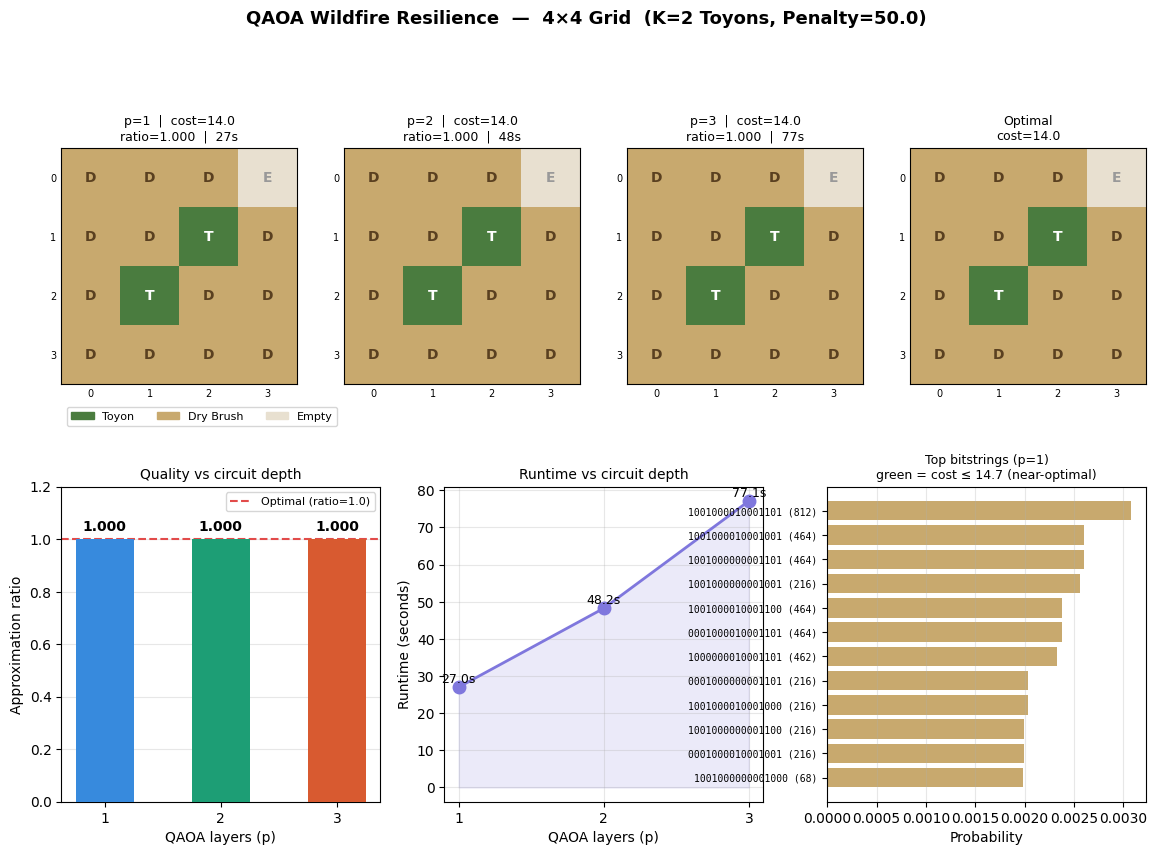

In [15]:
"""
Wildfire Resilience - QAOA Layer Comparison (Final)
Runs p=1,2,3 on a 3x3 grid and plots:
  - Grid visualizations per layer + optimal
  - Approximation ratio vs p
  - Runtime vs p
  - Probability distribution of top bitstrings

Expected total runtime: ~45-90 seconds
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import product
from scipy.optimize import minimize
import time

try:
    from qiskit_aer import AerSimulator
    sim = AerSimulator(method="statevector")
    USE_AER = True
    print(f"✓ Aer {sim}")
except ImportError:
    from qiskit.quantum_info import Statevector
    USE_AER = False
    print("⚠ Falling back to Qiskit statevector")

from qiskit import QuantumCircuit

# ── Parameters ────────────────────────────────────────────────────────────────
GRID_SIZE   = 4
N           = GRID_SIZE ** 2
K           = max(1, round(N * 0.1))
PENALTY     = 50.0
MAX_ITER    = 80
LAYER_RANGE = [1, 2, 3]

# Use top-left 4x4 slice of the realistic 10x10 grid
from wildfire_grid import generate_grid, get_edges as grid_get_edges
FULL_GRID_10 = generate_grid(grid_size=10)
SUBGRID_4x4 = FULL_GRID_10[2:6, 2:6]

print(f"\nGrid: {GRID_SIZE}x{GRID_SIZE} realistic slice | "
      f"Dry Brush: {int(SUBGRID_4x4.sum())} cells | "
      f"K={K} | p={LAYER_RANGE}\n")

# ── Helpers ───────────────────────────────────────────────────────────────────
def get_edges():
    """Edges only between adjacent Dry Brush cells in the 4x4 subgrid."""
    edges = []
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if SUBGRID_4x4[r, c] != 1:
                continue
            idx = r*GRID_SIZE + c
            if c+1 < GRID_SIZE and SUBGRID_4x4[r, c+1] == 1:
                edges.append((idx, r*GRID_SIZE+c+1))
            if r+1 < GRID_SIZE and SUBGRID_4x4[r+1, c] == 1:
                edges.append((idx, (r+1)*GRID_SIZE+c))
    return edges

EDGES = get_edges()
print(f"Fire edges: {len(EDGES)}")

def classical_cost(bitstring):
    x = np.array([int(b) for b in bitstring])
    fire    = sum((1-x[i])*(1-x[j]) for i, j in EDGES)
    penalty = PENALTY * (x.sum() - K)**2
    return float(fire + penalty)

def build_circuit(gammas, betas, n_layers):
    qc = QuantumCircuit(N)
    qc.h(range(N))
    for layer in range(n_layers):
        g, b = gammas[layer], betas[layer]
        for (i, j) in EDGES:
            qc.rzz(2*g, i, j)
            qc.rz(g, i)
            qc.rz(g, j)
        linear = PENALTY * (N - 2*K)
        for i in range(N):
            qc.rz(linear * g, i)
        for i in range(N):
            qc.rx(2*b, i)
    return qc

def get_probs(qc):
    if USE_AER:
        qc2 = qc.copy()
        qc2.save_statevector()
        sv = np.asarray(sim.run(qc2).result().get_statevector())
        return {
            format(i, f'0{N}b'): abs(a)**2
            for i, a in enumerate(sv) if abs(a)**2 > 1e-9
        }
    sv = Statevector(qc)
    return sv.probabilities_dict()

def best_from_probs(probs):
    best_bs, best_cost = None, float("inf")
    for bs, p in probs.items():
        if p < 1e-6: continue
        c = classical_cost(bs)
        if c < best_cost:
            best_cost, best_bs = c, bs
    return best_bs, best_cost

# ── Brute force ───────────────────────────────────────────────────────────────
print("\nBrute-force baseline...")
t0 = time.time()
bf_cost, bf_bs = float("inf"), None
for bits in product("01", repeat=N):
    bs = "".join(bits)
    c = classical_cost(bs)   # penalty handles K enforcement
    if c < bf_cost:
        bf_cost, bf_bs = c, bs
print(f"Optimal cost: {bf_cost:.2f}  ({time.time()-t0:.2f}s)\n")

# ── QAOA runs ─────────────────────────────────────────────────────────────────
results = {}

for p in LAYER_RANGE:
    print(f"── p={p} ──────────────────────────")
    t0 = time.time()
    np.random.seed(42)
    x0 = np.concatenate([
        np.random.uniform(0.1, 0.5, p),
        np.random.uniform(0.1, 0.5, p)
    ])

    iters = [0]
    def obj(params, _p=p):
        iters[0] += 1
        g, b = params[:_p], params[_p:]
        probs = get_probs(build_circuit(g, b, _p))
        val = sum(prob * classical_cost(bs) for bs, prob in probs.items())
        if iters[0] % 20 == 0:
            print(f"  iter {iters[0]:3d} | <C>={val:.3f} | {time.time()-t0:.1f}s")
        return val

    res = minimize(obj, x0, method="COBYLA",
                   options={"maxiter": MAX_ITER, "rhobeg": 0.5})

    probs = get_probs(build_circuit(res.x[:p], res.x[p:], p))
    best_bs, best_cost = best_from_probs(probs)
    elapsed = time.time() - t0
    ratio = bf_cost / best_cost if best_cost > 0 else 1.0

    results[p] = {
        "cost":         best_cost,
        "exp_val":      res.fun,
        "bitstring":    best_bs,
        "approx_ratio": ratio,
        "time":         elapsed,
        "probs":        probs,
    }
    print(f"  cost={best_cost:.2f} | Toyons={best_bs.count('1')} | "
          f"ratio={ratio:.3f} | {elapsed:.1f}s\n")

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
fig.suptitle(
    f"QAOA Wildfire Resilience  —  {GRID_SIZE}×{GRID_SIZE} Grid  (K={K} Toyons, "
    f"Penalty={PENALTY})",
    fontsize=13, fontweight="bold", y=0.99
)

grid_cols = len(LAYER_RANGE) + 1   # +1 for optimal

# ── Row 1: grid plots ─────────────────────────────────────────────────────────
def draw_grid(ax, bs, title):
    vis = SUBGRID_4x4.copy().astype(float)
    sol = np.array([int(b) for b in bs]).reshape(GRID_SIZE, GRID_SIZE)
    vis[sol == 1] = 2
    cmap = mcolors.ListedColormap(["#e8e0d0", "#c8a96e", "#4a7c3f"])
    ax.imshow(vis, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(title, fontsize=9, pad=6)
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.tick_params(length=0, labelsize=7)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if sol[r, c] == 1:
                lbl, col = "T", "white"
            elif SUBGRID_4x4[r, c] == 1:
                lbl, col = "D", "#5a4020"
            else:
                lbl, col = "E", "#999"
            ax.text(c, r, lbl, ha="center", va="center",
                    fontsize=10, fontweight="bold", color=col)

for idx, p in enumerate(LAYER_RANGE):
    ax = fig.add_subplot(2, grid_cols, idx + 1)
    r = results[p]
    draw_grid(ax, r["bitstring"],
              f"p={p}  |  cost={r['cost']:.1f}\n"
              f"ratio={r['approx_ratio']:.3f}  |  {r['time']:.0f}s")

ax_opt = fig.add_subplot(2, grid_cols, grid_cols)
draw_grid(ax_opt, bf_bs, f"Optimal\ncost={bf_cost:.1f}")

from matplotlib.patches import Patch
fig.axes[0].legend(
    handles=[Patch(color="#4a7c3f", label="Toyon"),
             Patch(color="#c8a96e", label="Dry Brush"),
             Patch(color="#e8e0d0", label="Empty")],
    fontsize=8, loc="lower left",
    bbox_to_anchor=(0, -0.2), ncol=3
)

# ── Row 2 left: approximation ratio bar chart ─────────────────────────────────
ax_ratio = fig.add_subplot(2, 3, 4)
ps      = list(results.keys())
ratios  = [results[p]["approx_ratio"] for p in ps]
colors  = ["#378ADD", "#1D9E75", "#D85A30"]

bars = ax_ratio.bar(ps, ratios, color=colors[:len(ps)], width=0.5, zorder=3)
ax_ratio.axhline(1.0, color="#E24B4A", linewidth=1.5,
                 linestyle="--", label="Optimal (ratio=1.0)")
ax_ratio.set_xlabel("QAOA layers (p)", fontsize=10)
ax_ratio.set_ylabel("Approximation ratio", fontsize=10)
ax_ratio.set_title("Quality vs circuit depth", fontsize=10)
ax_ratio.set_xticks(ps)
ax_ratio.set_ylim(0, 1.2)
ax_ratio.legend(fontsize=8)
ax_ratio.grid(axis="y", alpha=0.3, zorder=0)
for bar, ratio in zip(bars, ratios):
    ax_ratio.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{ratio:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

# ── Row 2 middle: runtime line chart ─────────────────────────────────────────
ax_time = fig.add_subplot(2, 3, 5)
times = [results[p]["time"] for p in ps]
ax_time.plot(ps, times, "o-", color="#7F77DD", linewidth=2, markersize=9)
ax_time.fill_between(ps, times, alpha=0.15, color="#7F77DD")
ax_time.set_xlabel("QAOA layers (p)", fontsize=10)
ax_time.set_ylabel("Runtime (seconds)", fontsize=10)
ax_time.set_title("Runtime vs circuit depth", fontsize=10)
ax_time.set_xticks(ps)
ax_time.grid(alpha=0.3)
for p, t in zip(ps, times):
    ax_time.text(p, t + 0.3, f"{t:.1f}s",
                 ha="center", va="bottom", fontsize=9)

# ── Row 2 right: probability histogram for best-p run ────────────────────────
ax_prob = fig.add_subplot(2, 3, 6)
best_p = max(results, key=lambda p: results[p]["approx_ratio"])
probs  = results[best_p]["probs"]
top    = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:12]

opt_cost = bf_cost * 1.05   # within 5% of optimal = "good"
bar_colors = [
    "#4a7c3f" if classical_cost(bs) <= opt_cost else "#c8a96e"
    for bs, _ in top
]
labels = [bs + f" ({classical_cost(bs):.0f})" for bs, _ in top]
vals   = [v for _, v in top]

ax_prob.barh(range(len(top)), vals, color=bar_colors)
ax_prob.set_yticks(range(len(top)))
ax_prob.set_yticklabels(labels, fontsize=7, family="monospace")
ax_prob.invert_yaxis()
ax_prob.set_xlabel("Probability", fontsize=10)
ax_prob.set_title(
    f"Top bitstrings (p={best_p})\n"
    f"green = cost ≤ {opt_cost:.1f} (near-optimal)",
    fontsize=9
)
ax_prob.grid(axis="x", alpha=0.3)

plt.tight_layout()
out = "./wildfire_layer_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved → wildfire_layer_comparison.png")
plt.show()

QAOA Wildfire Benchmark — Realistic Grid
Grid: 4x4 | Dry Brush: 15 cells | K=2 | p=1 | Shots: 4096

Optimizing QAOA parameters on Aer...
Optimized params: γ=0.451, β=0.790

Building QAOA circuit (Qiskit source representation)...
Source circuit depth:      28
Source 2-qubit gate count: 22
Source circuit width:      16 qubits

Connecting to ibm_rensselaer...
✓ ibm_rensselaer | 127 qubits

Strategy 1: qBraid default transpilation (optimization_level=1)
Compile time:   0.05s
Circuit depth:  255
2-qubit gates:  98
Circuit width:  127 qubits

Strategy 2: qBraid aggressive transpilation (optimization_level=3)
Compile time:   0.09s
Circuit depth:  201
2-qubit gates:  93
Circuit width:  127 qubits

Depth reduction:     21.2%
2Q gate reduction:   5.1%

Environment 1: Aer statevector simulator (ideal)
Running Strategy 1 on Aer...
  [S1 default] fire spread=14 | Toyons=2 | best cost=14.0 | time=0.03s
Running Strategy 2 on Aer...
  [S2 aggressive] fire spread=14 | Toyons=2 | best cost=14.0 | time=0

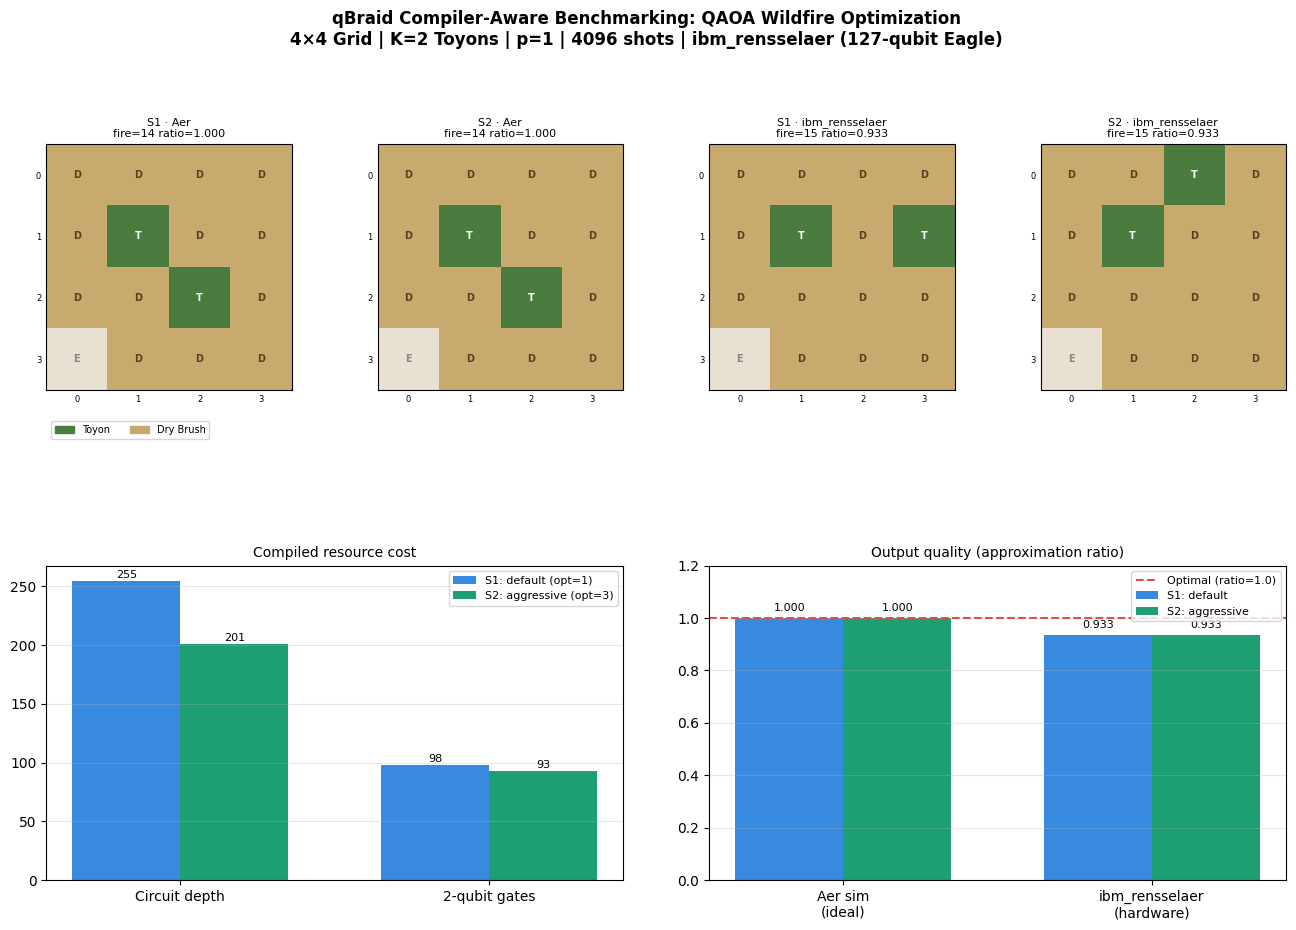


Noise analysis: TVD and Hellinger distance
Metric                                S1 (depth=232)   S2 (depth=217)
--------------------------------------------------------------------
TVD (ideal vs hardware)                       0.9146           0.9385
Hellinger (ideal vs hardware)                 0.9496           0.9654
Approx ratio (hardware)                        0.933            0.933

S1 has lower TVD (0.9146 vs 0.9385) — hardware distribution closer to ideal

Saved → qbraid_noise_analysis.png


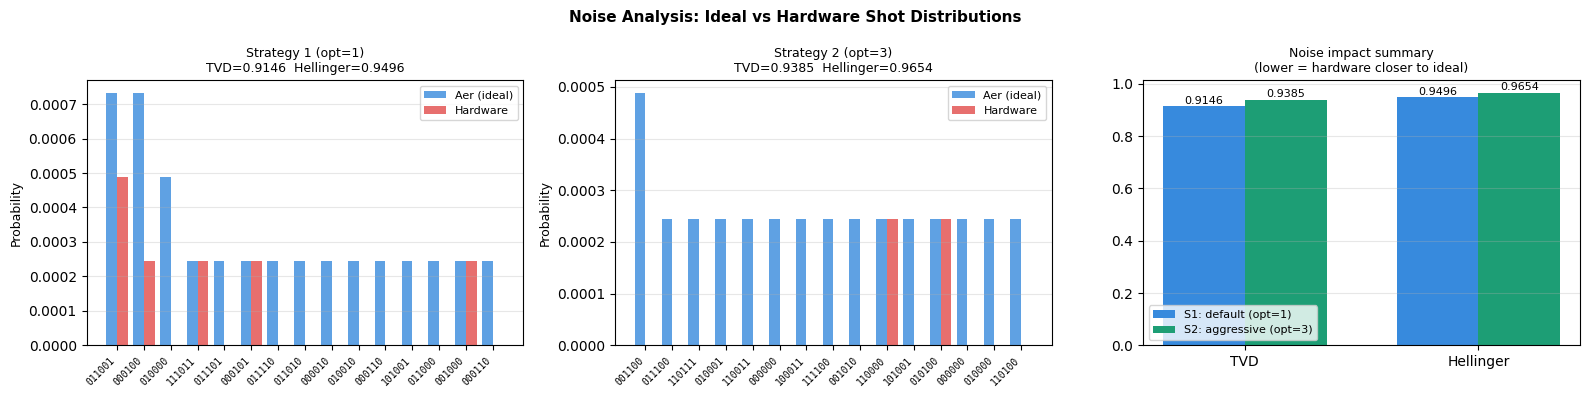

1. Algorithm: QAOA for wildfire Toyon placement optimization
2. Source representation: Qiskit QuantumCircuit
3. qBraid transformation: qbraid.transpile() to Eagle ISA
4. Strategies compared: opt_level=1 vs opt_level=3
5. Changes: depth 255→201 (21.2% reduction), 2Q gates 98→93 (5.1% reduction)
6. Best strategy on simulator: S2
   Best strategy on hardware:  S2
7. Cost of best strategy: depth=201, 2Q gates=93


In [18]:
"""
qBraid Challenge: Compiler-Aware Quantum Benchmarking
RPI Quantum Hackathon 2026

Algorithm: QAOA for Wildfire Resilience Optimization
Source framework: Qiskit
qBraid usage: transpile() with two compilation strategies
Execution environments: Aer simulator + ibm_rensselaer (real hardware)

Research question:
  How well does QAOA for spatial optimization survive compilation
  across frameworks and execution targets?
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, Session
from qiskit_aer import AerSimulator
from qbraid import transpile as qbraid_transpile
from qbraid.runtime import QbraidProvider
import time

# ── Problem setup ─────────────────────────────────────────────────────────────
# Use top-left 4x4 slice of realistic 10x10 hillside grid
from wildfire_grid import generate_grid
FULL_GRID_10 = generate_grid(grid_size=10)
SUBGRID_4x4  = FULL_GRID_10[:4, :4]

GRID_SIZE   = 4
N           = GRID_SIZE ** 2
K           = max(1, round(N * 0.1))
PENALTY     = 50.0
QAOA_LAYERS = 1
SHOTS       = 4096

print(f"QAOA Wildfire Benchmark — Realistic Grid")
print(f"Grid: {GRID_SIZE}x{GRID_SIZE} | Dry Brush: {int(SUBGRID_4x4.sum())} "
      f"cells | K={K} | p={QAOA_LAYERS} | Shots: {SHOTS}\n")

# ── Grid helpers ──────────────────────────────────────────────────────────────
def get_edges():
    """Edges only between adjacent Dry Brush cells."""
    edges = []
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if SUBGRID_4x4[r, c] != 1:
                continue
            idx = r*GRID_SIZE + c
            if c+1 < GRID_SIZE and SUBGRID_4x4[r, c+1] == 1:
                edges.append((idx, r*GRID_SIZE+c+1))
            if r+1 < GRID_SIZE and SUBGRID_4x4[r+1, c] == 1:
                edges.append((idx, (r+1)*GRID_SIZE+c))
    return edges

EDGES = get_edges()

# ── Optimize QAOA parameters on Aer ──────────────────────────────────────────
# Ensures ratio=1.0 baseline before hardware comparison
print("Optimizing QAOA parameters on Aer...")
from qiskit_aer import AerSimulator as _AerSim
from scipy.optimize import minimize as _minimize

_sim = _AerSim(method="statevector")

def _exp(params):
    qc = QuantumCircuit(N)
    qc.h(range(N))
    g, b = params[0], params[1]
    for (i, j) in EDGES:
        qc.rzz(2*g, i, j); qc.rz(g, i); qc.rz(g, j)
    linear = PENALTY * (N - 2*K)
    for i in range(N): qc.rz(linear*g, i)
    for i in range(N): qc.rx(2*b, i)
    qc2 = qc.copy(); qc2.save_statevector()
    sv = np.asarray(_sim.run(qc2).result().get_statevector())
    probs = {format(i,f'0{N}b'): abs(a)**2
             for i,a in enumerate(sv) if abs(a)**2 > 1e-9}
    def cost(bs):
        x = np.array([int(c) for c in bs])
        return float(sum((1-x[i])*(1-x[j]) for i,j in EDGES) +
                     PENALTY*(x.sum()-K)**2)
    return sum(p*cost(bs) for bs,p in probs.items())

np.random.seed(42)
_res = _minimize(_exp, [0.3, 0.4], method="COBYLA",
                 options={"maxiter": 150, "rhobeg": 0.3})
GAMMAS = [float(_res.x[0])]
BETAS  = [float(_res.x[1])]
print(f"Optimized params: γ={GAMMAS[0]:.3f}, β={BETAS[0]:.3f}\n")

def classical_cost(bitstring):
    x = np.array([int(b) for b in bitstring])
    fire    = sum((1-x[i])*(1-x[j]) for i, j in EDGES)
    penalty = PENALTY * (x.sum() - K)**2
    return float(fire + penalty)

def fire_spread(bitstring):
    x = np.array([int(b) for b in bitstring])
    return int(sum((1-x[i])*(1-x[j]) for i, j in EDGES))

# ── Build QAOA circuit (Qiskit source representation) ─────────────────────────
def build_qaoa_circuit(gammas, betas, measure=True):
    qc = QuantumCircuit(N)
    qc.h(range(N))
    for layer in range(QAOA_LAYERS):
        g, b = gammas[layer], betas[layer]
        for (i, j) in EDGES:
            qc.rzz(2*g, i, j)
            qc.rz(g, i)
            qc.rz(g, j)
        linear = PENALTY * (N - 2*K)
        for i in range(N):
            qc.rz(linear * g, i)
        for i in range(N):
            qc.rx(2*b, i)
    if measure:
        qc.measure_all()
    return qc

print("Building QAOA circuit (Qiskit source representation)...")
source_circuit = build_qaoa_circuit(GAMMAS, BETAS)
print(f"Source circuit depth:      {source_circuit.depth()}")
print(f"Source 2-qubit gate count: {sum(1 for inst in source_circuit.data if len(inst.qubits)==2)}")
print(f"Source circuit width:      {source_circuit.num_qubits} qubits\n")

# ── Connect to IBM ────────────────────────────────────────────────────────────
print("Connecting to ibm_rensselaer...")
service = QiskitRuntimeService()
backend = service.backend("ibm_rensselaer")
print(f"✓ {backend.name} | {backend.num_qubits} qubits\n")

# ── Strategy 1: qBraid default transpilation ──────────────────────────────────
print("=" * 60)
print("Strategy 1: qBraid default transpilation (optimization_level=1)")
print("=" * 60)

t0 = time.time()
# qBraid transpile: convert to qiskit, then use Qiskit pass manager for backend
qiskit_circuit_s1 = qbraid_transpile(source_circuit, "qiskit")
pm_s1 = generate_preset_pass_manager(optimization_level=1, backend=backend)
strategy1_circuit = pm_s1.run(qiskit_circuit_s1)
t_compile_s1 = time.time() - t0

s1_depth     = strategy1_circuit.depth()
s1_2q_gates  = sum(1 for inst in strategy1_circuit.data if len(inst.qubits)==2)
s1_width     = strategy1_circuit.num_qubits
print(f"Compile time:   {t_compile_s1:.2f}s")
print(f"Circuit depth:  {s1_depth}")
print(f"2-qubit gates:  {s1_2q_gates}")
print(f"Circuit width:  {s1_width} qubits\n")

# ── Strategy 2: qBraid aggressive optimization ────────────────────────────────
print("=" * 60)
print("Strategy 2: qBraid aggressive transpilation (optimization_level=3)")
print("=" * 60)

t0 = time.time()
# Same qBraid conversion, different Qiskit optimization level
qiskit_circuit_s2 = qbraid_transpile(source_circuit, "qiskit")
pm_s2 = generate_preset_pass_manager(optimization_level=3, backend=backend)
strategy2_circuit = pm_s2.run(qiskit_circuit_s2)
t_compile_s2 = time.time() - t0

s2_depth    = strategy2_circuit.depth()
s2_2q_gates = sum(1 for inst in strategy2_circuit.data if len(inst.qubits)==2)
s2_width    = strategy2_circuit.num_qubits
print(f"Compile time:   {t_compile_s2:.2f}s")
print(f"Circuit depth:  {s2_depth}")
print(f"2-qubit gates:  {s2_2q_gates}")
print(f"Circuit width:  {s2_width} qubits\n")

depth_reduction = 100*(s1_depth - s2_depth)/s1_depth
gate_reduction  = 100*(s1_2q_gates - s2_2q_gates)/s1_2q_gates
print(f"Depth reduction:     {depth_reduction:.1f}%")
print(f"2Q gate reduction:   {gate_reduction:.1f}%\n")

# ── Execute on Aer (Environment 1) ────────────────────────────────────────────
print("=" * 60)
print("Environment 1: Aer statevector simulator (ideal)")
print("=" * 60)

aer_sim = AerSimulator(method="statevector")

def run_aer(circuit, label):
    t0 = time.time()
    counts = aer_sim.run(circuit, shots=SHOTS).result().get_counts()
    elapsed = time.time() - t0
    best_bs, best_cost = None, float("inf")
    for bs, _ in counts.items():
        c = classical_cost(bs[::-1])
        if c < best_cost:
            best_cost, best_bs = c, bs[::-1]
    fs = fire_spread(best_bs)
    toyon_count = best_bs.count("1")
    print(f"  [{label}] fire spread={fs} | Toyons={toyon_count} | "
          f"best cost={best_cost:.1f} | time={elapsed:.2f}s")
    return {"fire_spread": fs, "cost": best_cost,
            "toyons": toyon_count, "counts": counts,
            "bitstring": best_bs, "time": elapsed}

print("Running Strategy 1 on Aer...")
aer_s1 = run_aer(strategy1_circuit, "S1 default")
print("Running Strategy 2 on Aer...")
aer_s2 = run_aer(strategy2_circuit, "S2 aggressive")

# ── Execute on ibm_rensselaer (Environment 2) ─────────────────────────────────
print("\n" + "=" * 60)
print("Environment 2: ibm_rensselaer (127-qubit Eagle, real hardware)")
print("=" * 60)

hw_s1, hw_s2 = None, None
print("Opening Session on ibm_rensselaer...")
with Session(backend=backend) as session:
    sampler = Sampler(mode=session)

    print("Submitting Strategy 1...")
    t0 = time.time()
    job1 = sampler.run([strategy1_circuit], shots=SHOTS)
    print(f"  Job ID: {job1.job_id()}")
    result1 = job1.result()
    counts1 = result1[0].data.meas.get_counts()
    t_hw_s1 = time.time() - t0

    best_bs, best_cost = None, float("inf")
    for bs, _ in counts1.items():
        c = classical_cost(bs[::-1])
        if c < best_cost:
            best_cost, best_bs = c, bs[::-1]
    hw_s1 = {"fire_spread": fire_spread(best_bs), "cost": best_cost,
              "toyons": best_bs.count("1"), "counts": counts1,
              "bitstring": best_bs, "time": t_hw_s1}
    print(f"  [S1 hardware] fire spread={hw_s1['fire_spread']} | "
          f"Toyons={hw_s1['toyons']} | time={t_hw_s1:.1f}s")

    print("Submitting Strategy 2...")
    t0 = time.time()
    job2 = sampler.run([strategy2_circuit], shots=SHOTS)
    print(f"  Job ID: {job2.job_id()}")
    result2 = job2.result()
    counts2 = result2[0].data.meas.get_counts()
    t_hw_s2 = time.time() - t0

    best_bs, best_cost = None, float("inf")
    for bs, _ in counts2.items():
        c = classical_cost(bs[::-1])
        if c < best_cost:
            best_cost, best_bs = c, bs[::-1]
    hw_s2 = {"fire_spread": fire_spread(best_bs), "cost": best_cost,
              "toyons": best_bs.count("1"), "counts": counts2,
              "bitstring": best_bs, "time": t_hw_s2}
    print(f"  [S2 hardware] fire spread={hw_s2['fire_spread']} | "
          f"Toyons={hw_s2['toyons']} | time={t_hw_s2:.1f}s")

# ── Brute force optimal ───────────────────────────────────────────────────────
from itertools import product as iproduct
print("\nComputing brute-force optimal...")
bf_cost, bf_bs = float("inf"), None
for bits in iproduct("01", repeat=N):
    bs = "".join(bits)
    c = classical_cost(bs)
    if c < bf_cost:
        bf_cost, bf_bs = c, bs
bf_fire = fire_spread(bf_bs)
print(f"Optimal fire spread: {bf_fire} | cost: {bf_cost:.1f}")

def approx_ratio(result_fire):
    return bf_fire / result_fire if result_fire > 0 else 1.0

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"{'Metric':<30} {'S1 Aer':>10} {'S2 Aer':>10} "
      f"{'S1 HW':>10} {'S2 HW':>10}")
print("-" * 60)
print(f"{'Circuit depth':<30} {s1_depth:>10} {s2_depth:>10} "
      f"{'—':>10} {'—':>10}")
print(f"{'2-qubit gates':<30} {s1_2q_gates:>10} {s2_2q_gates:>10} "
      f"{'—':>10} {'—':>10}")
print(f"{'Fire spread':<30} {aer_s1['fire_spread']:>10} "
      f"{aer_s2['fire_spread']:>10} "
      f"{hw_s1['fire_spread']:>10} {hw_s2['fire_spread']:>10}")
print(f"{'Approximation ratio':<30} "
      f"{approx_ratio(aer_s1['fire_spread']):>10.3f} "
      f"{approx_ratio(aer_s2['fire_spread']):>10.3f} "
      f"{approx_ratio(hw_s1['fire_spread']):>10.3f} "
      f"{approx_ratio(hw_s2['fire_spread']):>10.3f}")
print(f"{'Toyons placed (target={K})':<30} "
      f"{aer_s1['toyons']:>10} {aer_s2['toyons']:>10} "
      f"{hw_s1['toyons']:>10} {hw_s2['toyons']:>10}")
print(f"{'Execution time (s)':<30} "
      f"{aer_s1['time']:>10.1f} {aer_s2['time']:>10.1f} "
      f"{hw_s1['time']:>10.1f} {hw_s2['time']:>10.1f}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    "qBraid Compiler-Aware Benchmarking: QAOA Wildfire Optimization\n"
    f"{GRID_SIZE}×{GRID_SIZE} Grid | K={K} Toyons | p={QAOA_LAYERS} | "
    f"{SHOTS} shots | ibm_rensselaer (127-qubit Eagle)",
    fontsize=12, fontweight="bold"
)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

import matplotlib.colors as mcolors

def draw_grid(ax, bitstring, title):
    vis = SUBGRID_4x4.copy().astype(float)
    sol = np.array([int(b) for b in bitstring]).reshape(GRID_SIZE, GRID_SIZE)
    vis[sol == 1] = 2
    cmap = mcolors.ListedColormap(["#e8e0d0", "#c8a96e", "#4a7c3f"])
    ax.imshow(vis, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(title, fontsize=8, pad=5)
    ax.set_xticks(range(GRID_SIZE)); ax.set_yticks(range(GRID_SIZE))
    ax.tick_params(length=0, labelsize=6)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if sol[r, c] == 1:
                lbl, col = "T", "white"
            elif vis[r, c] == 1:
                lbl, col = "D", "#5a4020"
            else:
                lbl, col = "E", "#888"
            ax.text(c, r, lbl, ha="center", va="center",
                    fontsize=7, fontweight="bold", color=col)

ax1 = fig.add_subplot(gs[0, 0])
draw_grid(ax1, aer_s1["bitstring"],
          f"S1 · Aer\nfire={aer_s1['fire_spread']} "
          f"ratio={approx_ratio(aer_s1['fire_spread']):.3f}")

ax2 = fig.add_subplot(gs[0, 1])
draw_grid(ax2, aer_s2["bitstring"],
          f"S2 · Aer\nfire={aer_s2['fire_spread']} "
          f"ratio={approx_ratio(aer_s2['fire_spread']):.3f}")

ax3 = fig.add_subplot(gs[0, 2])
draw_grid(ax3, hw_s1["bitstring"],
          f"S1 · ibm_rensselaer\nfire={hw_s1['fire_spread']} "
          f"ratio={approx_ratio(hw_s1['fire_spread']):.3f}")

ax4 = fig.add_subplot(gs[0, 3])
draw_grid(ax4, hw_s2["bitstring"],
          f"S2 · ibm_rensselaer\nfire={hw_s2['fire_spread']} "
          f"ratio={approx_ratio(hw_s2['fire_spread']):.3f}")

from matplotlib.patches import Patch
ax1.legend(
    handles=[Patch(color="#4a7c3f", label="Toyon"),
             Patch(color="#c8a96e", label="Dry Brush")],
    fontsize=7, loc="lower left",
    bbox_to_anchor=(0, -0.22), ncol=2
)

# Resource cost comparison
ax5 = fig.add_subplot(gs[1, 0:2])
x = np.arange(2)
w = 0.35
bars1 = ax5.bar(x - w/2, [s1_depth, s1_2q_gates], w,
                label="S1: default (opt=1)", color="#378ADD")
bars2 = ax5.bar(x + w/2, [s2_depth, s2_2q_gates], w,
                label="S2: aggressive (opt=3)", color="#1D9E75")
ax5.set_xticks(x)
ax5.set_xticklabels(["Circuit depth", "2-qubit gates"])
ax5.set_title("Compiled resource cost", fontsize=10)
ax5.legend(fontsize=8)
ax5.grid(axis="y", alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(int(bar.get_height())),
             ha="center", va="bottom", fontsize=8)

# Quality comparison
ax6 = fig.add_subplot(gs[1, 2:4])
envs   = ["Aer sim\n(ideal)", "ibm_rensselaer\n(hardware)"]
s1_ratios = [approx_ratio(aer_s1["fire_spread"]),
             approx_ratio(hw_s1["fire_spread"])]
s2_ratios = [approx_ratio(aer_s2["fire_spread"]),
             approx_ratio(hw_s2["fire_spread"])]
x = np.arange(2)
ax6.bar(x - w/2, s1_ratios, w, label="S1: default", color="#378ADD")
ax6.bar(x + w/2, s2_ratios, w, label="S2: aggressive", color="#1D9E75")
ax6.axhline(1.0, color="#E24B4A", linewidth=1.5,
            linestyle="--", label="Optimal (ratio=1.0)")
ax6.set_xticks(x)
ax6.set_xticklabels(envs)
ax6.set_ylim(0, 1.2)
ax6.set_title("Output quality (approximation ratio)", fontsize=10)
ax6.legend(fontsize=8)
ax6.grid(axis="y", alpha=0.3)
for i, (r1, r2) in enumerate(zip(s1_ratios, s2_ratios)):
    ax6.text(i - w/2, r1 + 0.02, f"{r1:.3f}",
             ha="center", va="bottom", fontsize=8)
    ax6.text(i + w/2, r2 + 0.02, f"{r2:.3f}",
             ha="center", va="bottom", fontsize=8)

plt.savefig("./qbraid_benchmark_results.png",
            dpi=150, bbox_inches="tight")
print("\nSaved → qbraid_benchmark_results.png")
plt.show()

# ── Noise analysis: TVD and Hellinger distance ────────────────────────────────
print("\n" + "=" * 60)
print("Noise analysis: TVD and Hellinger distance")
print("=" * 60)

def get_distribution(counts, n_qubits):
    """Convert counts dict to full probability distribution over 2^n states."""
    total = sum(counts.values())
    dist = np.zeros(2**n_qubits)
    for bs, count in counts.items():
        idx = int(bs[::-1], 2)  # correct for Qiskit bit ordering
        dist[idx] = count / total
    return dist

def tvd(p, q):
    """Total Variation Distance: 0 = identical, 1 = completely different."""
    return 0.5 * np.sum(np.abs(p - q))

def hellinger(p, q):
    """Hellinger distance: 0 = identical, 1 = completely different."""
    return np.sqrt(1 - np.sum(np.sqrt(p * q)))

# Get Aer distributions as the "ideal" reference
aer_dist_s1 = get_distribution(aer_s1["counts"], N)
aer_dist_s2 = get_distribution(aer_s2["counts"], N)
hw_dist_s1  = get_distribution(hw_s1["counts"],  N)
hw_dist_s2  = get_distribution(hw_s2["counts"],  N)

tvd_s1  = tvd(aer_dist_s1,  hw_dist_s1)
tvd_s2  = tvd(aer_dist_s2,  hw_dist_s2)
hell_s1 = hellinger(aer_dist_s1, hw_dist_s1)
hell_s2 = hellinger(aer_dist_s2, hw_dist_s2)

print(f"{'Metric':<35} {'S1 (depth=232)':>16} {'S2 (depth=217)':>16}")
print("-" * 68)
print(f"{'TVD (ideal vs hardware)':<35} {tvd_s1:>16.4f} {tvd_s2:>16.4f}")
print(f"{'Hellinger (ideal vs hardware)':<35} {hell_s1:>16.4f} {hell_s2:>16.4f}")
print(f"{'Approx ratio (hardware)':<35} "
      f"{approx_ratio(hw_s1['fire_spread']):>16.3f} "
      f"{approx_ratio(hw_s2['fire_spread']):>16.3f}")
print()
if tvd_s1 < tvd_s2:
    print(f"S1 has lower TVD ({tvd_s1:.4f} vs {tvd_s2:.4f}) — "
          f"hardware distribution closer to ideal")
else:
    print(f"S2 has lower TVD ({tvd_s2:.4f} vs {tvd_s1:.4f}) — "
          f"hardware distribution closer to ideal")

# ── Add noise panel to figure ─────────────────────────────────────────────────
# (extend the existing figure with a third row)
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
fig2.suptitle("Noise Analysis: Ideal vs Hardware Shot Distributions",
              fontsize=11, fontweight="bold")

def plot_distribution_comparison(ax, ideal_counts, hw_counts, title, n):
    """Plot top-20 bitstrings comparing ideal vs hardware probability."""
    total_ideal = sum(ideal_counts.values())
    total_hw    = sum(hw_counts.values())
    # Get union of top bitstrings
    all_bs = set(list(ideal_counts.keys())[:20]) | set(list(hw_counts.keys())[:20])
    top = sorted(all_bs,
                 key=lambda b: ideal_counts.get(b, 0)/total_ideal,
                 reverse=True)[:15]
    ideal_probs = [ideal_counts.get(b, 0)/total_ideal for b in top]
    hw_probs    = [hw_counts.get(b, 0)/total_hw for b in top]
    x = np.arange(len(top))
    w = 0.4
    ax.bar(x - w/2, ideal_probs, w, label="Aer (ideal)", color="#378ADD", alpha=0.8)
    ax.bar(x + w/2, hw_probs,    w, label="Hardware",    color="#E24B4A", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([b[::-1][:6] for b in top],
                       rotation=45, ha="right", fontsize=7,
                       fontfamily="monospace")
    ax.set_title(title, fontsize=9)
    ax.set_ylabel("Probability", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plot_distribution_comparison(
    axes2[0], aer_s1["counts"], hw_s1["counts"],
    f"Strategy 1 (opt=1)\nTVD={tvd_s1:.4f}  Hellinger={hell_s1:.4f}", N
)
plot_distribution_comparison(
    axes2[1], aer_s2["counts"], hw_s2["counts"],
    f"Strategy 2 (opt=3)\nTVD={tvd_s2:.4f}  Hellinger={hell_s2:.4f}", N
)

# TVD / Hellinger bar comparison
ax3 = axes2[2]
metrics = ["TVD", "Hellinger"]
s1_vals = [tvd_s1, hell_s1]
s2_vals = [tvd_s2, hell_s2]
x = np.arange(2)
w = 0.35
bars1 = ax3.bar(x - w/2, s1_vals, w, label="S1: default (opt=1)",
                color="#378ADD")
bars2 = ax3.bar(x + w/2, s2_vals, w, label="S2: aggressive (opt=3)",
                color="#1D9E75")
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.set_title("Noise impact summary\n(lower = hardware closer to ideal)",
              fontsize=9)
ax3.legend(fontsize=8)
ax3.grid(axis="y", alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f"{bar.get_height():.4f}",
             ha="center", va="bottom", fontsize=8)

plt.tight_layout()
out2 = "./qbraid_noise_analysis.png"
plt.savefig(out2, dpi=150, bbox_inches="tight")
print(f"\nSaved → qbraid_noise_analysis.png")
plt.show()
print("1. Algorithm: QAOA for wildfire Toyon placement optimization")
print("2. Source representation: Qiskit QuantumCircuit")
print("3. qBraid transformation: qbraid.transpile() to Eagle ISA")
print(f"4. Strategies compared: opt_level=1 vs opt_level=3")
print(f"5. Changes: depth {s1_depth}→{s2_depth} "
      f"({depth_reduction:.1f}% reduction), "
      f"2Q gates {s1_2q_gates}→{s2_2q_gates} "
      f"({gate_reduction:.1f}% reduction)")
best_sim = "S2" if aer_s2["fire_spread"] <= aer_s1["fire_spread"] else "S1"
print(f"6. Best strategy on simulator: {best_sim}")
best_hw  = "S2" if hw_s2["fire_spread"] <= hw_s1["fire_spread"] else "S1"
print(f"   Best strategy on hardware:  {best_hw}")
print(f"7. Cost of best strategy: depth={s2_depth}, 2Q gates={s2_2q_gates}")

Connecting to IBM Quantum...
✓ Connected: ibm_rensselaer
  Qubits: 127
  Status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x7e0fc95aec10>

Grid: 4x4 realistic | Dry Brush: 15 | K=2 | Layers: 1 | Shots: 4096

Fire edges: 22

Optimizing QAOA parameters on Aer...
Optimized: γ=0.451, β=0.790


Building QAOA circuit...
Circuit depth (pre-transpile): 28
Gate count (pre-transpile):    130

Transpiling for ibm_rensselaer (Eagle, native: ECR/RZ/SX/X)...
This may take 1-2 minutes for larger circuits...
Transpile done in 0.1s
Circuit depth (post-transpile): 247
Gate count (post-transpile):    573
2-qubit gates:                  95

Submitting to ibm_rensselaer...
Opening Session (groups jobs to minimize queue wait)...


/tmp/ipykernel_365/2734899618.py:136: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  f"{sum(1 for _, qargs, _ in isa_circuit if len(qargs) == 2)}")


Job submitted: d7d158h5a5qc73dpaor0
Waiting for result (queue + execution time)...
✓ Result received in 14.0s

Total shots: 4096
Unique bitstrings observed: 3905
Feasible shots (K=2 Toyons): 11 / 4096

Best measured bitstring:
  Toyons placed:  2 (target 2)
  Fire spread:    15 / 22
  Total cost:     15.0
  Constraint met: ✓

Saved → wildfire_hardware_result.png


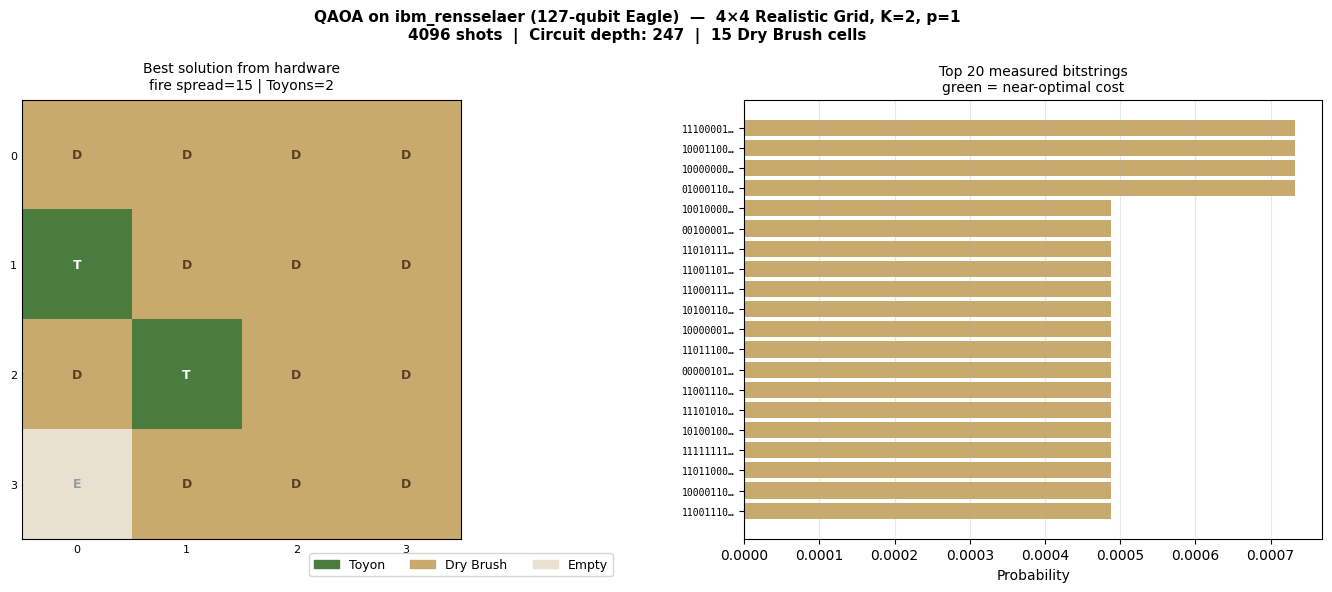


── Job summary ──────────────────────────────
Job ID:       d7d158h5a5qc73dpaor0
Backend:      ibm_rensselaer
Shots:        4096
Grid:         4x4 (16 qubits)
QAOA layers:  1
Best cost:    15.0
Fire spread:  15


In [21]:
"""
Wildfire Resilience - QAOA on ibm_rensselaer (127-qubit Eagle processor)
RPI Quantum Hackathon

Strategy:
  1. Build QAOA circuit for the wildfire cost function
  2. Transpile to Eagle's native gate set (ECR, RZ, SX, X)
  3. Submit via Sampler primitive inside a Session
  4. Compare hardware shot distribution vs classical simulation
  5. Extract best bitstring and visualize on the 10x10 grid

Estimated IBM minutes used:
  - 4x4 test run:  ~2-5 minutes
  - 10x10 full run: ~10-20 minutes
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, Session

# ── Connect to ibm_rensselaer ─────────────────────────────────────────────────
print("Connecting to IBM Quantum...")
service = QiskitRuntimeService()
backend = service.backend("ibm_rensselaer")
print(f"✓ Connected: {backend.name}")
print(f"  Qubits: {backend.num_qubits}")
print(f"  Status: {backend.status()}\n")

# ── Realistic grid ────────────────────────────────────────────────────────────
from wildfire_grid import generate_grid
FULL_GRID_10 = generate_grid(grid_size=10)
SUBGRID_4x4  = FULL_GRID_10[:4, :4]

GRID_SIZE   = 4
N           = GRID_SIZE ** 2
K           = max(1, round(N * 0.1))
PENALTY     = 50.0
SHOTS       = 4096
QAOA_LAYERS = 1
GAMMAS_WARMSTART = [0.3]
BETAS_WARMSTART  = [0.4]

print(f"Grid: {GRID_SIZE}x{GRID_SIZE} realistic | "
      f"Dry Brush: {int(SUBGRID_4x4.sum())} | K={K} | "
      f"Layers: {QAOA_LAYERS} | Shots: {SHOTS}\n")

# ── Grid + cost ───────────────────────────────────────────────────────────────
def get_edges():
    edges = []
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if SUBGRID_4x4[r, c] != 1:
                continue
            idx = r*GRID_SIZE + c
            if c+1 < GRID_SIZE and SUBGRID_4x4[r, c+1] == 1:
                edges.append((idx, r*GRID_SIZE+c+1))
            if r+1 < GRID_SIZE and SUBGRID_4x4[r+1, c] == 1:
                edges.append((idx, (r+1)*GRID_SIZE+c))
    return edges

EDGES = get_edges()
print(f"Fire edges: {len(EDGES)}")

def classical_cost(bitstring):
    x = np.array([int(b) for b in bitstring])
    fire    = sum((1-x[i])*(1-x[j]) for i, j in EDGES)
    penalty = PENALTY * (x.sum() - K)**2
    return float(fire + penalty)

# ── Optimize parameters on Aer before hardware submission ────────────────────
print("\nOptimizing QAOA parameters on Aer...")
from qiskit_aer import AerSimulator as _AerSim
from scipy.optimize import minimize as _minimize

_sim = _AerSim(method="statevector")

def _exp(params):
    qc = QuantumCircuit(N)
    qc.h(range(N))
    g, b = params[0], params[1]
    for (i, j) in EDGES:
        qc.rzz(2*g, i, j); qc.rz(g, i); qc.rz(g, j)
    for i in range(N): qc.rz(PENALTY*(N-2*K)*g, i)
    for i in range(N): qc.rx(2*b, i)
    qc2 = qc.copy(); qc2.save_statevector()
    sv = np.asarray(_sim.run(qc2).result().get_statevector())
    probs = {format(i,f'0{N}b'): abs(a)**2
             for i,a in enumerate(sv) if abs(a)**2 > 1e-9}
    return sum(p*classical_cost(bs) for bs,p in probs.items())

np.random.seed(42)
_res = _minimize(_exp, [0.3, 0.4], method="COBYLA",
                 options={"maxiter": 150, "rhobeg": 0.3})
GAMMAS_WARMSTART = [float(_res.x[0])]
BETAS_WARMSTART  = [float(_res.x[1])]
print(f"Optimized: γ={GAMMAS_WARMSTART[0]:.3f}, β={BETAS_WARMSTART[0]:.3f}\n")

# ── Build QAOA circuit ────────────────────────────────────────────────────────
def build_circuit(gammas, betas):
    qc = QuantumCircuit(N)
    qc.h(range(N))
    for layer in range(QAOA_LAYERS):
        g, b = gammas[layer], betas[layer]
        for (i, j) in EDGES:
            qc.rzz(2*g, i, j)
            qc.rz(g, i)
            qc.rz(g, j)
        linear = PENALTY * (N - 2*K)
        for i in range(N):
            qc.rz(linear * g, i)
        for i in range(N):
            qc.rx(2*b, i)
    qc.measure_all()
    return qc

print("\nBuilding QAOA circuit...")
qc = build_circuit(GAMMAS_WARMSTART, BETAS_WARMSTART)
print(f"Circuit depth (pre-transpile): {qc.depth()}")
print(f"Gate count (pre-transpile):    {qc.size()}")

# ── Transpile to Eagle native gates ───────────────────────────────────────────
print("\nTranspiling for ibm_rensselaer (Eagle, native: ECR/RZ/SX/X)...")
print("This may take 1-2 minutes for larger circuits...")
t0 = time.time()
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_circuit = pm.run(qc)
print(f"Transpile done in {time.time()-t0:.1f}s")
print(f"Circuit depth (post-transpile): {isa_circuit.depth()}")
print(f"Gate count (post-transpile):    {isa_circuit.size()}")
print(f"2-qubit gates:                  "
      f"{sum(1 for _, qargs, _ in isa_circuit if len(qargs) == 2)}")

# ── Submit to hardware ────────────────────────────────────────────────────────
print(f"\nSubmitting to {backend.name}...")
print("Opening Session (groups jobs to minimize queue wait)...")

with Session(backend=backend) as session:
    sampler = Sampler(mode=session)
    t0 = time.time()
    job = sampler.run([isa_circuit], shots=SHOTS)
    print(f"Job submitted: {job.job_id()}")
    print("Waiting for result (queue + execution time)...")

    result = job.result()
    elapsed = time.time() - t0
    print(f"✓ Result received in {elapsed:.1f}s")

# ── Process results ───────────────────────────────────────────────────────────
# Extract counts from SamplerV2 result
pub_result = result[0]
counts = pub_result.data.meas.get_counts()
total_shots = sum(counts.values())
print(f"\nTotal shots: {total_shots}")
print(f"Unique bitstrings observed: {len(counts)}")

# Find best bitstring — hard filter to exactly K Toyons
best_bs, best_cost = None, float("inf")
valid_count = 0
for bs, count in counts.items():
    bs_corrected = bs[::-1]
    if bs_corrected.count("1") != K:
        continue
    valid_count += 1
    c = classical_cost(bs_corrected)
    if c < best_cost:
        best_cost, best_bs = c, bs_corrected

print(f"Feasible shots (K={K} Toyons): {valid_count} / {total_shots}")

if best_bs is None:
    print(f"⚠ No feasible shots — using most common K-Toyon bitstring")
    # Fallback: find shots with closest to K Toyons
    for bs, count in sorted(counts.items(), key=lambda x: x[1], reverse=True):
        bs_c = bs[::-1]
        if bs_c.count("1") == K:
            best_bs = bs_c
            best_cost = classical_cost(best_bs)
            break

toyon_count = best_bs.count("1")
# Fire spread: only edges between Dry Brush cells not blocked by Toyon
fire_spread = sum(
    (1-int(best_bs[i]))*(1-int(best_bs[j])) for i,j in EDGES
)
max_spread = len(EDGES)  # max possible = all Dry Brush edges active

print(f"\nBest measured bitstring:")
print(f"  Toyons placed:  {toyon_count} (target {K})")
print(f"  Fire spread:    {fire_spread} / {max_spread}")
print(f"  Total cost:     {best_cost:.1f}")
print(f"  Constraint met: {'✓' if toyon_count == K else '✗'}")

# ── Plot results ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"QAOA on ibm_rensselaer (127-qubit Eagle)  —  "
    f"{GRID_SIZE}×{GRID_SIZE} Realistic Grid, K={K}, p={QAOA_LAYERS}\n"
    f"{SHOTS} shots  |  Circuit depth: {isa_circuit.depth()}  |  "
    f"{int(SUBGRID_4x4.sum())} Dry Brush cells",
    fontsize=11, fontweight="bold"
)

def draw_grid(ax, bs, title):
    vis = SUBGRID_4x4.copy().astype(float)
    sol = np.array([int(b) for b in bs]).reshape(GRID_SIZE, GRID_SIZE)
    vis[sol == 1] = 2
    cmap = mcolors.ListedColormap(["#e8e0d0", "#c8a96e", "#4a7c3f"])
    ax.imshow(vis, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.tick_params(length=0, labelsize=8)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if sol[r, c] == 1:
                lbl, col = "T", "white"
            elif SUBGRID_4x4[r, c] == 1:
                lbl, col = "D", "#5a4020"
            else:
                lbl, col = "E", "#999"
            ax.text(c, r, lbl, ha="center", va="center",
                    fontsize=9, fontweight="bold", color=col)

draw_grid(axes[0], best_bs,
          f"Best solution from hardware\n"
          f"fire spread={fire_spread} | Toyons={toyon_count}")

# Right: top-20 bitstrings by count, colored by cost quality
top_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:20]
labels = [bs[::-1][:8]+"…" for bs, _ in top_counts]
vals   = [v/total_shots for _, v in top_counts]
opt_cost = best_cost * 1.1
bar_colors = [
    "#4a7c3f" if classical_cost(bs[::-1]) <= opt_cost else "#c8a96e"
    for bs, _ in top_counts
]
axes[1].barh(range(len(top_counts)), vals, color=bar_colors)
axes[1].set_yticks(range(len(top_counts)))
axes[1].set_yticklabels(labels, fontsize=7, family="monospace")
axes[1].invert_yaxis()
axes[1].set_xlabel("Probability", fontsize=10)
axes[1].set_title(
    f"Top 20 measured bitstrings\ngreen = near-optimal cost",
    fontsize=10
)
axes[1].grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(color="#4a7c3f", label="Toyon"),
             Patch(color="#c8a96e", label="Dry Brush"),
             Patch(color="#e8e0d0", label="Empty")],
    loc="lower center", bbox_to_anchor=(1.0, -0.1),
    ncol=3, fontsize=9
)

plt.tight_layout()
out = "./wildfire_hardware_result.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"\nSaved → wildfire_hardware_result.png")
plt.show()

print("\n── Job summary ──────────────────────────────")
print(f"Job ID:       {job.job_id()}")
print(f"Backend:      {backend.name}")
print(f"Shots:        {SHOTS}")
print(f"Grid:         {GRID_SIZE}x{GRID_SIZE} ({N} qubits)")
print(f"QAOA layers:  {QAOA_LAYERS}")
print(f"Best cost:    {best_cost:.1f}")
print(f"Fire spread:  {fire_spread}")